# Student Mental Health Prediction — Logistic Regression
This notebook **only** implements and evaluates a Logistic Regression model.

The dataset has already been cleaned and split into train/test (80:20) by another team member. **No preprocessing, feature engineering, scaling, encoding, or additional splitting is performed here.**

## Step 1: Import Required Libraries

In [21]:
# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [22]:
from google.colab import files
uploaded = files.upload()

Saving X_test.csv to X_test.csv
Saving X_train.csv to X_train.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv


## Step 2: Load the Provided Train/Test Datasets
Update the file paths below if needed (e.g., upload the CSVs to Colab first, or mount Google Drive).

In [23]:
X_train = pd.read_csv("X_train.csv").astype(float)  # one-hot columns load as bool; cast to float for the network
X_test = pd.read_csv("X_test.csv").astype(float)
y_train = pd.read_csv("y_train.csv")["Distressed"]
y_test = pd.read_csv("y_test.csv")["Distressed"]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)
print("\nFeature columns:")
print(X_train.columns.tolist())

X_train shape: (19433, 39)
X_test shape : (4859, 39)
y_train shape: (19433,)
y_test shape : (4859,)

Feature columns:
['age', 'gad7_q1', 'gad7_q2', 'gad7_q3', 'gad7_q4', 'gad7_q5', 'gad7_q6', 'gad7_q7', 'isi_q1', 'isi_q2', 'isi_q3', 'isi_q4', 'isi_q5', 'isi_q6', 'isi_q7', 'pss_q1', 'pss_q2', 'pss_q3', 'pss_q4', 'pss_q5', 'pss_q6', 'pss_q7', 'pss_q8', 'pss_q9', 'pss_q10', 'pss_q11', 'pss_q12', 'pss_q13', 'pss_q14', 'gender_male', "edu_bachelor's degree", 'edu_doctorate degree', "edu_master's degree", 'smoke_former smoker (cumulative smoking >10 packs), but not in the past year', 'smoke_never smokes', 'smoke_occasional smoker (cumulative smoking <10 packs)', 'drink_drank in the past (more than once a week), but not in the past year', 'drink_drinks occasionally (less than once a week)', 'drink_never drinks']


## Step 3: Create the Logistic Regression Model

In [24]:
# random_state ensures reproducibility
# max_iter increased so the solver has enough iterations to converge
model = LogisticRegression(random_state=42, max_iter=1000)

## Step 4: Train the Model

In [25]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Step 5: Make Predictions on Test Data

In [26]:
y_pred = model.predict(X_test)                     # Predicted class labels (0 or 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]    # Predicted probability of class "1" (for ROC-AUC)

## Step 6: Calculate Evaluation Metrics

In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

print("===== MODEL EVALUATION METRICS =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(cm)

===== MODEL EVALUATION METRICS =====
Accuracy  : 0.9603
Precision : 0.7397
Recall    : 0.4106
F1 Score  : 0.5281
ROC-AUC   : 0.9613

Confusion Matrix:
[[4558   38]
 [ 155  108]]


## Step 7: Display the Confusion Matrix

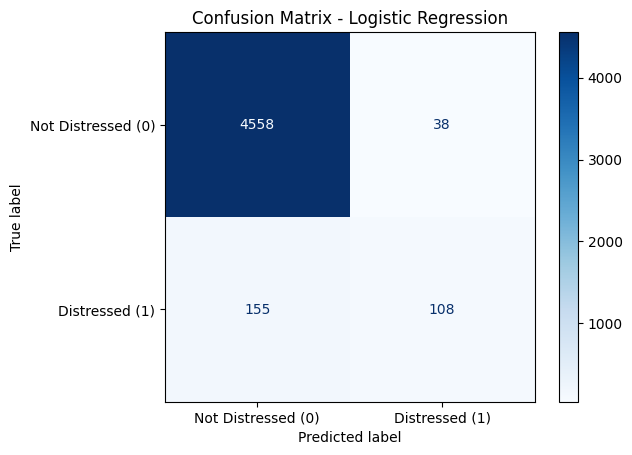

In [28]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Distressed (0)", "Distressed (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Step 8: Plot the ROC Curve

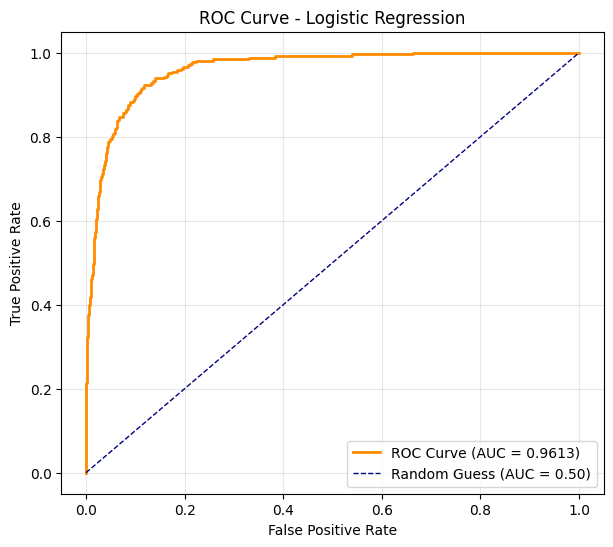

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", linewidth=1, linestyle="--", label="Random Guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()